# Scope of the American Parliamentary Debate Association (APDA)

This section will analzye the scope and patterns seen within the APDA circuit from 2004-2005 season to the 2025-2026 season using the following metrics: tournaments and teams participating. The goal of this section is to understand the scope of APDA and its expected impact in coming years, as well as understand areas that may need to be investigated to improve involvement..

## Tournaments

The first metric to understand is the number of tournaments in APDA between 2005 to 2025. In order to begin understanding this, I will import the tournment data. This data includes the host school, the time the tournament took place, the number of teams, the number of novice debaters, and any special markers for that tournamnet (ProAms, Online, etc). For the first analysis we will only need information on the tournament and the time, as only this is relevant. I will aggregate the number of tournaments per year with a SQL query.

In [4]:
import duckdb

con = duckdb.connect()

query = """
SELECT season, COUNT (*) as num_tournaments
FROM "Data_Curation_Data/Tournaments.csv"
GROUP BY season
ORDER BY season ASC
"""

df_count_tournaments = con.execute(query).df()

I will now plot the the number of tournaments per year below.

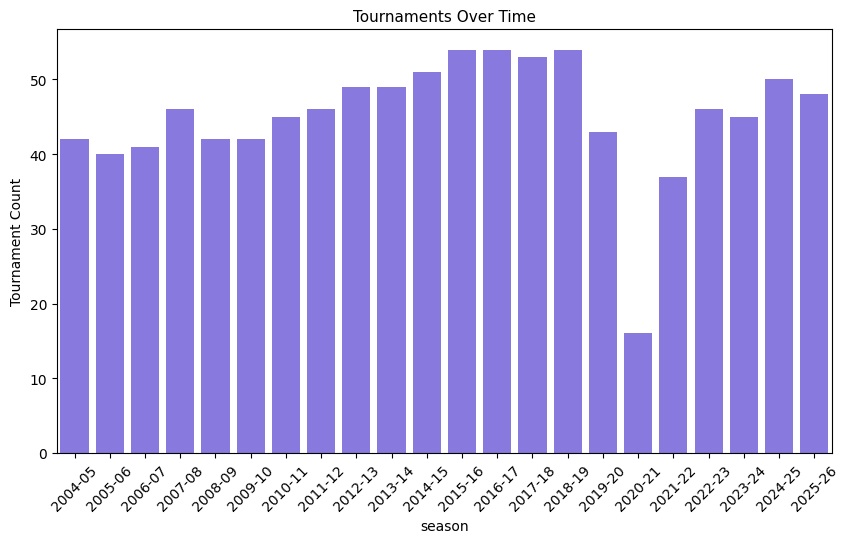

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.barplot(df_count_tournaments, x="season", y="num_tournaments", color="mediumslateblue", ax=ax)

ax.set_title(f"Tournaments Over Time", fontsize=11)
ax.set_ylabel("Tournament Count")
ax.tick_params(axis="x", rotation=45)

plt.show()

There seems to be a few interesting things about this graph. For starters, it seems there was a pretty steady increase in number of tournaments per year between 2004 and 2018. Second, there was a significant disruption in the number of tournaments in the years 2019-2021, likely due to COVID-19 which disrupted college classes and restricted tournaments from being in-person. Finally, the number of tournments post COVID-19 (the years 2022-2025, did not seems to fully bounce back to its pandemic state. In order to visualize this further, I will sort the data, so we may see each of these observations clearer.

In [6]:
query = """
SELECT season, num_tournaments
FROM df_count_tournaments
WHERE (
    (season != '2019-20') AND
    (season != '2020-21') AND
    (season != '2021-22') AND
    (season != '2022-23') AND
    (season != '2023-24') AND
    (season != '2024-25') AND
    (season != '2025-26') 
)
"""
df_count_tournaments_pre_covid = con.execute(query).df()

In [7]:
query = """
SELECT season, num_tournaments
FROM df_count_tournaments
WHERE (
    (season == '2019-20') OR
    (season == '2020-21')
)
"""
df_count_tournaments_covid = con.execute(query).df()

In [8]:
query = """
SELECT season, num_tournaments
FROM df_count_tournaments
WHERE (
    (season == '2021-22') OR
    (season == '2022-23') OR
    (season == '2023-24') OR
    (season == '2024-25') OR
    (season == '2025-26') 
)
"""
df_count_tournaments_post_covid = con.execute(query).df()

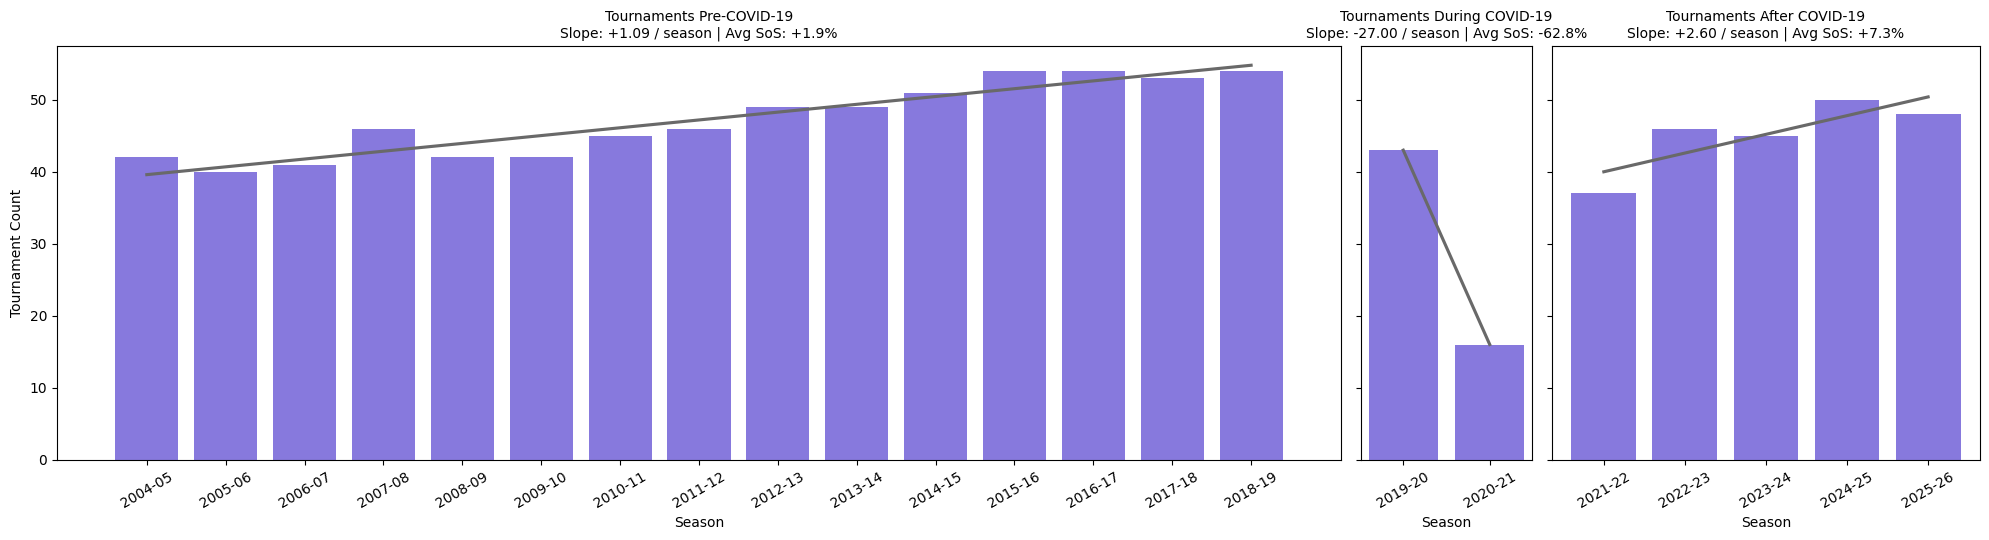

In [49]:
fig, ax = plt.subplots(
    1, 3, figsize=(20, 5.5),
    sharey=True,
    gridspec_kw={"width_ratios": [
        len(df_count_tournaments_pre_covid),
        len(df_count_tournaments_covid),
        len(df_count_tournaments_post_covid),
    ]}
)
x_positions_1 = np.arange(len(df_count_tournaments_pre_covid))
slope_1, _ = np.polyfit(x_positions_1, df_count_tournaments_pre_covid["num_tournaments"], 1)
avg_pct_1 = df_count_tournaments_pre_covid["num_tournaments"].pct_change().mean() * 100

x_positions_2 = np.arange(len(df_count_tournaments_covid))
slope_2, _ = np.polyfit(x_positions_2, df_count_tournaments_covid["num_tournaments"], 1)
avg_pct_2 = df_count_tournaments_covid["num_tournaments"].pct_change().mean() * 100

x_positions_3 = np.arange(len(df_count_tournaments_post_covid))
slope_3, _ = np.polyfit(x_positions_3, df_count_tournaments_post_covid["num_tournaments"], 1)
avg_pct_3 = df_count_tournaments_post_covid["num_tournaments"].pct_change().mean() * 100

sns.barplot(df_count_tournaments_pre_covid, x="season", y="num_tournaments", color="mediumslateblue", ax=ax[0],)
sns.regplot(x=x_positions_1, y=df_count_tournaments_pre_covid["num_tournaments"], ax=ax[0], scatter=False, color="dimgray", label="Trend", ci=None)
ax[0].set_title(f"Tournaments Pre-COVID-19\nSlope: {slope_1:+.2f} / season | Avg SoS: {avg_pct_1:+.1f}%", fontsize=10)
ax[0].set_ylabel("Tournament Count")
ax[0].set_xlabel("Season")
ax[0].tick_params(axis="x", rotation=30)

sns.barplot(df_count_tournaments_covid, x="season", y="num_tournaments", color="mediumslateblue", ax=ax[1],)
sns.regplot(x=x_positions_2, y=df_count_tournaments_covid["num_tournaments"], ax=ax[1], scatter=False, color="dimgray", label="Trend", ci=None)
ax[1].set_title(f"Tournaments During COVID-19\nSlope: {slope_2:+.2f} / season | Avg SoS: {avg_pct_2:+.1f}%", fontsize=10)
ax[1].set_ylabel("Tournament Count")
ax[1].set_xlabel("Season")
ax[1].tick_params(axis="x", rotation=30)

sns.barplot(df_count_tournaments_post_covid, x="season", y="num_tournaments", color="mediumslateblue", ax=ax[2],)
sns.regplot(x=x_positions_3, y=df_count_tournaments_post_covid["num_tournaments"], ax=ax[2], scatter=False, color="dimgray", label="Trend", ci=None)
ax[2].set_title(f"Tournaments After COVID-19\nSlope: {slope_3:+.2f} / season | Avg SoS: {avg_pct_3:+.1f}%", fontsize=10)
ax[2].set_ylabel("Tournament Count")
ax[2].set_xlabel("Season")
ax[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

We can perform a linear regression in order to see the relationship of tournaments over time more clearly.

In [11]:
from scipy import stats
def trend_test(df, col="num_tournaments"):
    x = np.arange(len(df))
    y = df[col].values
    result = stats.linregress(x, y)
    return result.slope, result.pvalue, result.rvalue**2

slope_1, p_1, r2_1 = trend_test(df_count_tournaments_pre_covid)
slope_2, p_2, r2_2 = trend_test(df_count_tournaments_covid)
slope_3, p_3, r2_3 = trend_test(df_count_tournaments_post_covid)

print(f"Pre-COVID:  slope={slope_1:+.2f}, p={p_1:.4f}, R²={r2_1:.2f}")
print(f"COVID:      slope={slope_2:+.2f}, p={p_2:.4f}, R²={r2_2:.2f}")
print(f"Post-COVID: slope={slope_3:+.2f}, p={p_3:.4f}, R²={r2_3:.2f}")

Pre-COVID:  slope=+1.09, p=0.0000, R²=0.89
COVID:      slope=-27.00, p=0.0000, R²=1.00
Post-COVID: slope=+2.60, p=0.0840, R²=0.68


From this data we can see in the Pre-COVID analysis we have a slope of +1.09 and a p-value 0f 0.000, well under 0.05, so this is statistically significant. We also have a relatively high R² value of 0.89, so we can conclude that there is in face a general increase over time of about 1.09 tournament per year in the Pre-COVID time frame. During COVID there is a slope of -27.00 and the R² value is a perfect 1.00, so a sharp and consistent decrease which we can see with the graph. Our p-value is also 0.000, so we can conclude there was definetely a decrease in rounds during this period. However, there is only two datapoints so that should be considered. Finally we can see in the post COVID time perion that there is a near high slope of +2.60, however, it is much less statistically sound with a p-value of 0.0840 and a medium R² of 0.68. This is likely because our data is flat and a little noisy, especially towards the end. Similarly, it might be because we have only five data points. We cannot reject the null hypothesis that there is not an increase over time with this data. For now, we can conclude that there was a steady increase in the number of tournaments between 2004 and 2018, a disruption from 2018-2021, and a period which has not quite been recovery from 2021 onward.

In order to test the disruption we can fit a trend based on our increasing pre-COVID-19 timeline, then see where the actual post COVID-19 data measures up to this trend.

In [34]:
pre_covid_df = df_count_tournaments[df_count_tournaments["season"] <= "2018-19"].reset_index(drop=True)
x_pre = np.arange(len(pre_covid_df))
slope, intercept, *_ = stats.linregress(x_pre, pre_covid_df["num_tournaments"])

post_covid_df = df_count_tournaments[df_count_tournaments["season"] >= "2021-22"].reset_index(drop=True)
x_post = np.arange(len(pre_covid_df), len(pre_covid_df) + len(post_covid_df))
predicted = slope * x_post + intercept

residuals = post_covid_df["num_tournaments"].values - predicted
t_stat, p_value = stats.ttest_1samp(residuals, 0) 
print(f"Predicted (trend continued): {predicted}")
print(f"Actual: {post_covid_df['num_tournaments'].values}")
print(f"t={t_stat:.2f}, p={p_value:.4f}")

Predicted (trend continued): [55.88571429 56.97142857 58.05714286 59.14285714 60.22857143]
Actual: [37 46 45 50 48]
t=-7.82, p=0.0014


The following data shows that according the the trend occuring between 2004 and 2018, we should have seen 55-60 tournaments per year between 2021 and 2026, however, in actuality, we have only seen 37-48. This t test had a p-value of 0.0014, which is less than 0.05 and is statistically significant in showing that the post-COVID-19 tournaments per year are well below the predicted trend from 2004 to 2018. In the 2025-2026 season we are 12 tournamnets or 20% below projection.

## Teams

The next measure I will take is the number of teams attending tournaments, this is a better measure of overall participation in debate. I will sum the number of team registrations per season. This does not mean that each team is unique but that each count represents one registration as a unique tournament. Each team is made up of two debaters who face off against another team, teams could be between two debaters of different schools, but often they are not, and a single debater can choose to have a consistent partner or change as often as they want.

In [35]:
query = """
SELECT season, SUM(teams) as num_teams
FROM "Data_Curation_Data/Tournaments.csv"
GROUP BY season
ORDER BY season ASC
"""

df_count_teams = con.execute(query).df()

The first thing we can do is graph the participation over time and see how this lines up with the information we have already gained by analyzing tournaments over time.

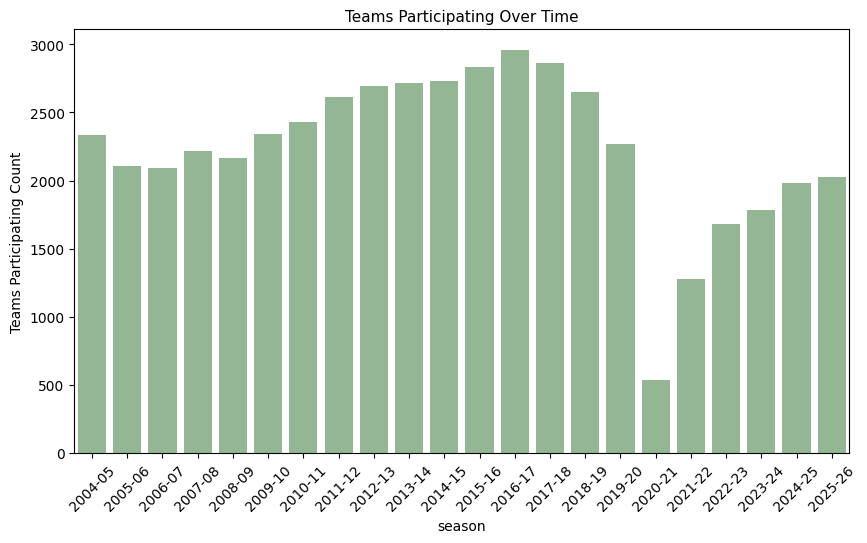

In [36]:
fig, ax = plt.subplots(figsize=(10, 5.5))

sns.barplot(df_count_teams, x="season", y="num_teams", color="darkseagreen", ax=ax)

ax.set_title(f"Teams Participating Over Time", fontsize=11)
ax.set_ylabel("Teams Participating Count")
ax.tick_params(axis="x", rotation=45)

plt.show()

From this, we can see a similar general trend, but with a few distinctions. For similarities, it seems that there might be a general increasing trend between 2004 and 2018, a decreasing trend between 2019 and 2020, and possibly an increasing trend from 2021 to 2026. Distinctly, however, the number of rounds from post COVID-19 to pre COVID-19 seems proportionally lower than the number of tournaments in the same timeframe.

I will separate the three time frames for easier analysis.

In [37]:
query = """
SELECT season, num_teams
FROM df_count_teams
WHERE (
    (season != '2019-20') AND
    (season != '2020-21') AND
    (season != '2021-22') AND
    (season != '2022-23') AND
    (season != '2023-24') AND
    (season != '2024-25') AND
    (season != '2025-26') 
)
"""
df_count_participation_pre_covid = con.execute(query).df()

In [38]:
query = """
SELECT season, num_teams
FROM df_count_teams
WHERE (
    (season == '2019-20') OR
    (season == '2020-21')
)
"""
df_count_participation_covid = con.execute(query).df()

In [39]:
query = """
SELECT season, num_teams
FROM df_count_teams
WHERE (
    (season == '2021-22') OR
    (season == '2022-23') OR
    (season == '2023-24') OR
    (season == '2024-25') OR
    (season == '2025-26') 
)
"""
df_count_participation_post_covid = con.execute(query).df()

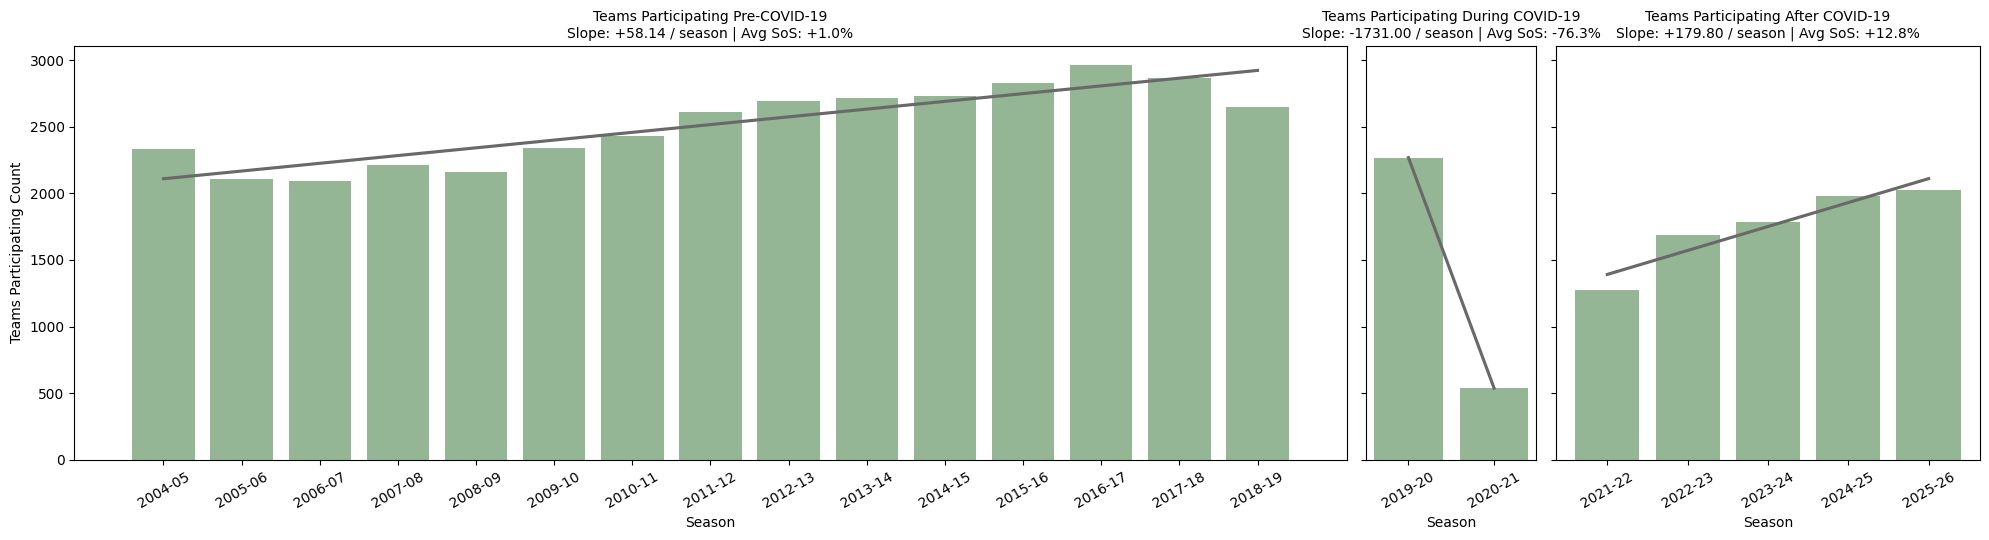

In [50]:
fig, ax = plt.subplots(
    1, 3, figsize=(20, 5.5),
    sharey=True,
    gridspec_kw={"width_ratios": [
        len(df_count_participation_pre_covid),
        len(df_count_participation_covid),
        len(df_count_participation_post_covid),
    ]}
)
x_positions_1 = np.arange(len(df_count_participation_pre_covid))
slope_1, _ = np.polyfit(x_positions_1, df_count_participation_pre_covid["num_teams"], 1)
avg_pct_1 = df_count_participation_pre_covid["num_teams"].pct_change().mean() * 100

x_positions_2 = np.arange(len(df_count_participation_covid))
slope_2, _ = np.polyfit(x_positions_2, df_count_participation_covid["num_teams"], 1)
avg_pct_2 = df_count_participation_covid["num_teams"].pct_change().mean() * 100

x_positions_3 = np.arange(len(df_count_participation_post_covid))
slope_3, _ = np.polyfit(x_positions_3, df_count_participation_post_covid["num_teams"], 1)
avg_pct_3 = df_count_participation_post_covid["num_teams"].pct_change().mean() * 100

sns.barplot(df_count_participation_pre_covid, x="season", y="num_teams", color="darkseagreen", ax=ax[0],)
sns.regplot(x=x_positions_1, y=df_count_participation_pre_covid["num_teams"], ax=ax[0], scatter=False, color="dimgray", label="Trend", ci=None)
ax[0].set_title(f"Teams Participating Pre-COVID-19\nSlope: {slope_1:+.2f} / season | Avg SoS: {avg_pct_1:+.1f}%", fontsize=10)
ax[0].set_ylabel("Teams Participating Count")
ax[0].set_xlabel("Season")
ax[0].tick_params(axis="x", rotation=30)

sns.barplot(df_count_participation_covid, x="season", y="num_teams", color="darkseagreen", ax=ax[1],)
sns.regplot(x=x_positions_2, y=df_count_participation_covid["num_teams"], ax=ax[1], scatter=False, color="dimgray", label="Trend", ci=None)
ax[1].set_title(f"Teams Participating During COVID-19\nSlope: {slope_2:+.2f} / season | Avg SoS: {avg_pct_2:+.1f}%", fontsize=10)
ax[1].set_ylabel("Teams Participating Count")
ax[1].set_xlabel("Season")
ax[1].tick_params(axis="x", rotation=30)

sns.barplot(df_count_participation_post_covid, x="season", y="num_teams", color="darkseagreen", ax=ax[2],)
sns.regplot(x=x_positions_3, y=df_count_participation_post_covid["num_teams"], ax=ax[2], scatter=False, color="dimgray", label="Trend", ci=None)
ax[2].set_title(f"Teams Participating After COVID-19\nSlope: {slope_3:+.2f} / season | Avg SoS: {avg_pct_3:+.1f}%", fontsize=10)
ax[2].set_ylabel("Teams Participating Count")
ax[2].set_xlabel("Season")
ax[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [41]:
def trend_test(df, col="num_teams"):
    x = np.arange(len(df))
    y = df[col].values
    result = stats.linregress(x, y)
    return result.slope, result.pvalue, result.rvalue**2

slope_1, p_1, r2_1 = trend_test(df_count_participation_pre_covid)
slope_2, p_2, r2_2 = trend_test(df_count_participation_covid)
slope_3, p_3, r2_3 = trend_test(df_count_participation_post_covid)

print(f"Pre-COVID:  slope={slope_1:+.2f}, p={p_1:.4f}, R²={r2_1:.2f}")
print(f"COVID:      slope={slope_2:+.2f}, p={p_2:.4f}, R²={r2_2:.2f}")
print(f"Post-COVID: slope={slope_3:+.2f}, p={p_3:.4f}, R²={r2_3:.2f}")

Pre-COVID:  slope=+58.14, p=0.0000, R²=0.79
COVID:      slope=-1731.00, p=0.0000, R²=1.00
Post-COVID: slope=+179.80, p=0.0144, R²=0.90


From the above we can draw three conclusions. The first is that there is a positive relationship between teams registered and time between 2004 and 2018 with a slope of +58.14, a moderately high R² of 0.79, and a statistically significant p-value of 0.0000 which is less than 0.05. Secondly, there is a decrease in number of teams registering during the two years of COVID-19 with a slope of -1731.00, p-value of 0.0000, and R² of 1.00, however, it is again important to keep in mind that there are only two years. Interesting, the post COVID-19 years are also increasing with a slope of +179.80, a high R² of 0.90 and a p-value of 0.0144 which, unlike the tournaments, is significant. This shows that even though the tournaments may not be increasing, the team participation is since the end of COVID-19.

Similar to how we predicted the tournament based of trendlines, we can see how the team participation measure up the with trend line from 2004 to 2018.

In [43]:
pre_covid_df = df_count_teams[df_count_teams["season"] <= "2018-19"].reset_index(drop=True)
x_pre = np.arange(len(pre_covid_df))
slope, intercept, *_ = stats.linregress(x_pre, pre_covid_df["num_teams"])

post_covid_df = df_count_teams[df_count_teams["season"] >= "2021-22"].reset_index(drop=True)
x_post = np.arange(len(pre_covid_df), len(pre_covid_df) + len(post_covid_df))
predicted = slope * x_post + intercept

residuals = post_covid_df["num_teams"].values - predicted
t_stat, p_value = stats.ttest_1samp(residuals, 0) 
print(f"Predicted (trend continued): {predicted}")
print(f"Actual: {post_covid_df['num_teams'].values}")
print(f"t={t_stat:.2f}, p={p_value:.4f}")

Predicted (trend continued): [2981.41904762 3039.5547619  3097.69047619 3155.82619048 3213.96190476]
Actual: [1276. 1684. 1786. 1982. 2026.]
t=-14.00, p=0.0002


From this t test, we have a p-value of 0.0002, which is below 0.05, and a t stat of -14.00, this shows a significant different from the post COVID-19 era measurements and the actual recorded participation. We can see that over 2021 to 2026, the number of teams was expected to grow from 2981 to 3214, however it started at 1276 and grew to 2026. This is 1,188 teams and 37% less than projected. 

## Insights and Conclusions

From the above data, we can see that APDA participation and tournaments was hit hard by the COVID-19 pandemic. We should have expected 20% more tournaments and 37% more teams participating then we have had in actuallity. Despite this, the number of teams participating is increasing steadly, and the number of tournaments is fluctuating, but not decreasing. 

The next things to consider are how we can increase involvement and participation in ADPA debate, are there schools that had teams shut down and never recover during COVID-19? Do teams need time to rebuild their roster sizes after a few years of low novice turnout? Are their regional differences to the disturbances? These are questions I would like to investigate in futher pages.